This notebook implements a comprehensive, automated machine learning pipeline from raw data ingestion to model deployment and ethical auditing. It is divided into four main sections:

**1. Automated EDA and Feature Engineering Pipeline (Initial Cells)**
This section focuses on preparing the raw input CSV data for machine learning. Its capabilities include:

*   **Data Cleaning:** Automatically identifies and removes duplicate entries, imputes missing numerical values using the median, and categorical values with the mode. It also handles outliers by capping them using the Interquartile Range (IQR) method.
*   **Feature Engineering:** Transforms raw features by scaling numerical variables using `StandardScaler`, encoding categorical features using `LabelEncoder`, and generating binned categorical features from continuous data.
*   **Applied EDA:** Generates visual distributions (histograms) and correlation heatmaps to help understand data relationships and patterns.
*   **Feature Selection & Dimensionality Reduction:** Evaluates three feature selection methods (Filter via Variance Threshold, Wrapper via RFE, Embedded via Random Forest) and dynamically selects the best method based on PCA's ability to retain 99% variance with the fewest components. Finally, Principal Component Analysis (PCA) is applied to the selected features to reduce dimensionality while preserving 99% of the data's information.
*   **Automated Reporting:** Generates a detailed, downloadable HTML Exploratory Data Analysis report using `ydata-profiling` and a processed CSV file of the cleaned, engineered, and PCA-reduced dataset.

**2. Supervised Model Training and Development (Cell ab849f60)**
This part handles the training, evaluation, and storage of various supervised machine learning models. Key steps include:

*   **Data Loading:** Uploads the processed CSV dataset (output from the previous stage).
*   **Data Splitting:** Divides the dataset into training (70%) and testing (30%) sets for model development and unbiased evaluation.
*   **Model Initialization & Tuning:** Sets up and fine-tunes five common machine learning models: Logistic Regression, Decision Tree, Random Forest, XGBoost, and Support Vector Machine (SVM), using `GridSearchCV` to find optimal hyperparameters.
*   **Model Evaluation:** Assesses each model's performance using a suite of metrics including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and R-Squared.
*   **Visualizations:** Generates ROC curves and prediction scatter plots for each model to visualize performance.
*   **Reproducibility:** Saves all trained models, along with training configurations and evaluation results, into a dedicated 'models' directory.

**3. Explainability and Bias Audit (Cell 40daf8c9)**
This section focuses on interpreting the best-performing model and auditing it for potential biases:

*   **Best Model Identification:** Automatically selects the top-performing model from the training phase.
*   **Pipeline Reconstruction:** Rebuilds the entire data transformation pipeline (scaling, PCA, model) to enable explainability insights directly on the original features, not just the PCA components.
*   **Global Explainability (SHAP):** Utilizes SHAP (Shapley Additive Explanations) to quantify the contribution of each original feature to the model's overall predictions, providing a global understanding of feature importance.
*   **Feature Interaction (PDP & ICE):** Generates Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE) plots to visualize how changes in specific original features impact the model's output (e.g., probability of fraud).
*   **Bias & Fairness Audit:** Conducts a fairness assessment across sensitive groups (proxied by `avg_monthly_balance` in this example), calculating metrics like Disparate Impact, Demographic Parity, and Equal Opportunity to detect potential discrimination.
*   **Ethical Reporting:** Synthesizes all explainability and fairness findings into a comprehensive Markdown report.

**4. Model Deployment as a Flask API (Cell 9e9da662)**
This final section demonstrates how to deploy the selected best model as a web service:

*   **Preprocessor Reconstruction and Saving:** Rebuilds and saves the `StandardScaler` and `PCA` transformers used during training, ensuring consistency when processing new data for prediction.
*   **Model Loading:** Loads a user-selected best model from the 'models' directory.
*   **Flask API Setup:** Defines a Flask web application with a `/predict` endpoint that accepts JSON data, preprocesses it using the saved transformers, and returns a prediction.
*   **Background Server:** Runs the Flask API in a background thread to allow for immediate testing within the Colab environment.
*   **API Testing:** Allows users to upload a JSON payload, which is then sent to the running API endpoint to demonstrate its prediction capabilities.
*   **Graceful Shutdown:** Ensures the Flask server is properly shut down after testing.

In essence, the entire notebook provides a robust, end-to-end framework for developing, evaluating, explaining, and deploying machine learning models, with a strong emphasis on automation and ethical considerations.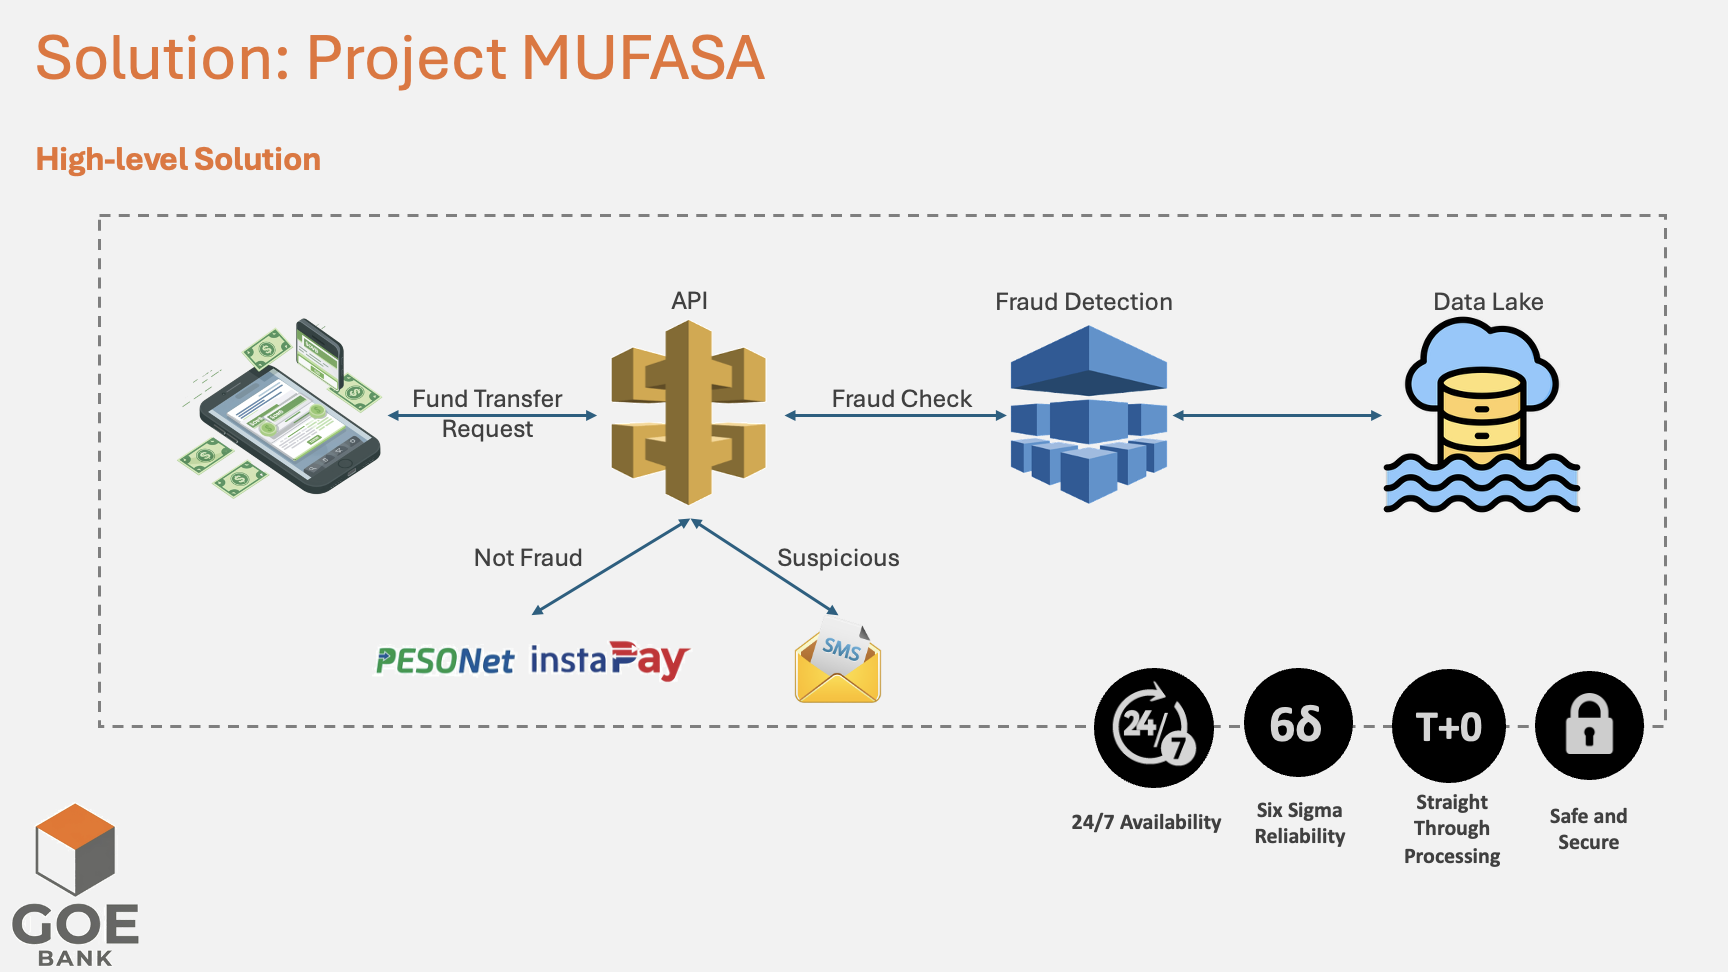

Continuing pipeline with the user-selected 'Wrapper' method...

Conclusion: The user-selected 'Wrapper' method is being used.
It retained 9 features and requires 9 PCA components to successfully capture 99% of the data's variance.

--- Final Selected Features ---
1. transaction_amount
2. device_risk_score
3. anomaly_score
4. account_age_days
5. avg_monthly_balance
6. daily_transaction_count
7. geo_distance_km
8. session_duration_minutes
9. transaction_velocity_score
-------------------------------

--- Step 6: Dimensionality Reduction (PCA) ---
Narrative: Dimensionality reduction is applied to remove multicollinearity and compress the feature space.
We apply PCA strictly on the 9 robust features selected above to capture 99% variance.

Original feature count (after selection): 9
PCA reduced feature count (explaining 99% variance): 9


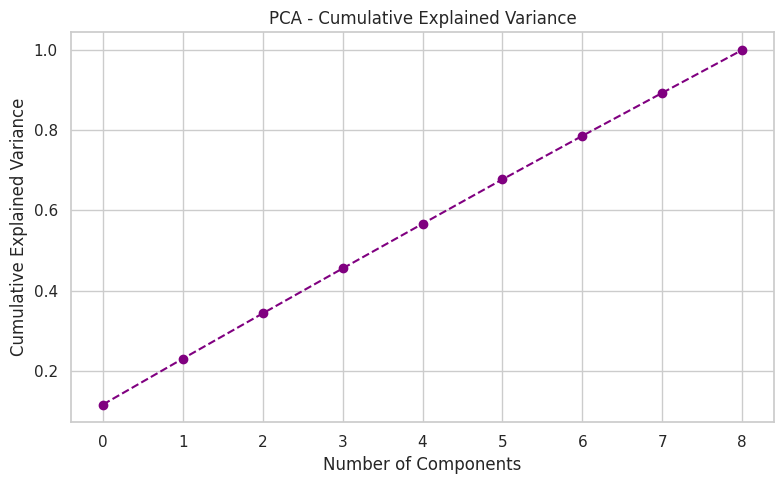


--- Step 7: Output & Downloadable Report ---
Generating comprehensive EDA report (this may take a minute)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 66.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EDA Report and Processed Data downloaded. Process complete!


In [ ]:
!pip install -q ydata-profiling # Installed for generating the comprehensive final HTML report

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io
import os
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
from google.colab import files
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, RFE, SelectFromModel
from sklearn.decomposition import PCA
from ydata_profiling import ProfileReport

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# =====================================================================
# STEP 0: Generate README.md for GitHub
# =====================================================================
print("--- Step 0: Generating README.md ---")
readme_content = """# Automated EDA and Feature Engineering Pipeline

## Overview
This repository contains a reproducible, dynamic Python pipeline built in Google Colab that performs automated Exploratory Data Analysis (EDA) and Feature Engineering on any uploaded CSV dataset.

## Capabilities / Steps Performed
1. **Data Cleaning:** Automatically identifies and drops duplicates. Imputes missing numerical values with the median and categorical values with the mode. Outliers are handled dynamically via the Interquartile Range (IQR) capping method. A summary of these actions is provided in the output.
2. **Feature Engineering:** Scales numeric variables (StandardScaler), encodes categorical features (LabelEncoder), and generates binned categorical features for continuous data.
3. **Applied EDA:** Produces visual distributions and correlation heatmaps to extract data relationships.
4. **Feature Selection & Dimensionality Reduction (Comprehensive Narrative):**
   - **Feature Selection:** To avoid the curse of dimensionality and remove noisy variables, the pipeline evaluates three distinct feature selection methods:
     - *Filter Method (Variance Threshold)*: Evaluates intrinsic properties of features independently.
     - *Wrapper Method (RFE)*: Iteratively evaluates feature combinations.
     - *Embedded Method (Random Forest)*: Learns feature importance intrinsically during training.
   - **Balancing Robustness and Practicality:** To ensure optimal performance without overfitting, the script uses at least 30% of the dataset for evaluation. It then applies a 99% variance threshold check using PCA across the features selected by all three methods. It dynamically selects the method that requires the fewest Principal Components to satisfy the 99% variance threshold. This guarantees we pick the most practical (compact) yet robust set of features.
   - **Dimensionality Reduction (PCA):** Finally, Principal Component Analysis (PCA) is applied to the dynamically selected features to project the data into a lower-dimensional space, removing multicollinearity while strictly preserving 99% of the original data's information.
5. **Automated Reporting:** Generates a comprehensive, downloadable HTML EDA report using `ydata-profiling`.

## Usage Instructions
1. Open the Jupyter Notebook / Colab environment.
2. Run the cells sequentially.
3. When prompted, upload your standard `.csv` file.
4. You will be prompted to enter the name of the **target variable** for predictive modeling.
5. Upon completion, the pipeline automatically downloads:
   - `EDA_Feature_Engineering_Report_of_[filename].html`: The comprehensive profiling report.
   - `Processed_Data_[filename].csv`: The cleaned, engineered, and PCA-reduced dataset ready for modeling.

## Requirements
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- ydata-profiling
"""

with open("README.md", "w") as f:
    f.write(readme_content)

display(Markdown(readme_content))
print("README.md generated and displayed above.\n")

# =====================================================================
# STEP 1: Upload File and Setup
# =====================================================================
print("--- Step 1: Data Upload ---")
print("Please upload your dataset (CSV format):")
uploaded = files.upload()

if len(uploaded) > 0:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"\nSuccessfully loaded: {filename}")
    print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("No file uploaded. Please run the cell again and upload a file.")
    raise SystemExit("Execution stopped as no file was uploaded.")

print(f"\nAvailable columns:\n{df.columns.tolist()}")
target_col = input("\nEnter the name of the target variable column (leave blank to use the last column): ").strip()

if not target_col or target_col not in df.columns:
    target_col = df.columns[-1]
    print(f"Defaulting target column to: '{target_col}'\n")
else:
    print(f"Target column set to: '{target_col}'\n")

# Main pipeline wrapped in a function to execute after widget selection
def run_pipeline_initial(df_selected, target_col):
    numeric_cols = df_selected.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df_selected.select_dtypes(exclude=['number']).columns.tolist()

    # Remove target_col from these lists for feature-specific operations
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print(f"\nNumeric columns remaining: {len(numeric_cols)}")
    print(f"Categorical columns remaining: {len(categorical_cols)}")

    # =====================================================================
    # STEP 2: Clean Data (Nulls, Duplicates, and Outliers)
    # =====================================================================
    print("\n--- Step 2: Data Cleaning ---")
    df_clean = df_selected.copy()

    # Track cleaning stats
    initial_rows = df_clean.shape[0]
    initial_nulls = df_clean.isnull().sum().sum()

    # Drop Duplicates (applies to entire row, including target)
    df_clean = df_clean.drop_duplicates()
    duplicates_removed = initial_rows - df_clean.shape[0]

    # Handle Nulls for FEATURES (target handled separately if necessary)
    for col in numeric_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

    # Handle Nulls for TARGET COLUMN (if any)
    if target_col in df_selected.columns and df_clean[target_col].isnull().sum() > 0:
        target_nulls_before_handling = df_clean[target_col].isnull().sum()
        if df_selected[target_col].nunique() < 20: # Treat as categorical for null handling logic
            df_clean.dropna(subset=[target_col], inplace=True)
            print(f"Dropped {target_nulls_before_handling} rows with missing values in the target column '{target_col}' to preserve class integrity.")
        else: # Treat as numeric for null handling logic
            df_clean[target_col].fillna(df_clean[col].median(), inplace=True)
            print(f"Imputed {target_nulls_before_handling} missing values in the numeric target column '{target_col}' with its median.")


    # Handle Outliers using IQR method (Capping) for FEATURES ONLY
    outliers_capped = 0
    for col in numeric_cols: # Only iterate through actual feature numeric_cols
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_capped += ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

    print("\n--- Data Cleaning Summary Output ---")
    print(f"1. Duplicates Removed: {duplicates_removed}")
    print(f"2. Null Values Imputed for Features: {initial_nulls - df_clean[target_col].isnull().sum()} (Median for numeric, Mode for categorical)")
    print(f"3. Outliers Capped for Features: {outliers_capped} (Using IQR boundaries)")
    print("------------------------------------\n")

    # Re-evaluate numeric_cols and categorical_cols after cleaning as target_col might have been removed
    numeric_cols_after_cleaning = df_clean.select_dtypes(include=['number']).columns.tolist()
    categorical_cols_after_cleaning = df_clean.select_dtypes(exclude=['number']).columns.tolist()
    if target_col in numeric_cols_after_cleaning:
        numeric_cols_after_cleaning.remove(target_col)
    if target_col in categorical_cols_after_cleaning:
        categorical_cols_after_cleaning.remove(target_col)


    # =====================================================================
    # STEP 3: Engineer Features (Scaling, Encoding, Binning)
    # =====================================================================
    print("--- Step 3: Feature Engineering ---")
    df_engineered = df_clean.copy()

    # Tracking applied engineering
    encoded_features = []
    scaled_features = []
    binned_features = []

    # Encoding Categorical Variables
    le = LabelEncoder()
    for col in categorical_cols_after_cleaning: # Use updated list
        df_engineered[col] = le.fit_transform(df_engineered[col].astype(str))
        encoded_features.append(col)
    print(f"Categorical variables encoded to numeric labels: {encoded_features}")

    # Binning: Create a binned version of the first numeric feature
    if len(numeric_cols_after_cleaning) > 0: # Use updated list
        first_num_col = numeric_cols_after_cleaning[0]
        est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
        df_engineered[f'{first_num_col}_binned'] = est.fit_transform(df_engineered[[first_num_col]])
        binned_features.append(f'{first_num_col}_binned')
        print(f"Created a binned feature: '{first_num_col}_binned' (Low, Medium, High categories).")

    # Scaling Numeric Features
    if numeric_cols_after_cleaning: # Use updated list
        scaler = StandardScaler()
        df_engineered[numeric_cols_after_cleaning] = scaler.fit_transform(df_engineered[numeric_cols_after_cleaning])
        scaled_features = numeric_cols_after_cleaning.copy()
        print(f"Numeric features standard scaled (mean=0, variance=1): {scaled_features}\n")

    # =====================================================================
    # STEP 4: Applied EDA
    # =====================================================================
    print("--- Step 4: Applied EDA ---")
    plt.figure(figsize=(10, 8))
    corr_matrix = df_engineered.corr(numeric_only=True)
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap of Features')
    plt.tight_layout()
    plt.show()

    num_plots = min(len(numeric_cols_after_cleaning), 4)
    if num_plots > 0:
        fig, axes = plt.subplots(1, num_plots, figsize=(15, 4))
        if num_plots == 1: axes = [axes]
        for i in range(num_plots):
            sns.histplot(df_clean[numeric_cols_after_cleaning[i]], kde=True, ax=axes[i], color='skyblue')
            axes[i].set_title(f'Distribution: {numeric_cols_after_cleaning[i]}')
        plt.tight_layout()
        plt.show()

    # =====================================================================
    # STEP 5: Feature Selection & Evaluation (Balancing Practicality/Robustness)
    # =====================================================================
    print("\n--- Step 5: Feature Selection ---")
    X = df_engineered.drop(columns=[target_col])
    y = df_engineered[target_col]

    # Use at least 30% of data for feature selection
    sample_size = max(int(X.shape[0] * 0.30), min(20000, X.shape[0]))
    print(f"Using {sample_size} rows for feature selection evaluation (>= 30% of data)...")

    sample_indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_eval = X.iloc[sample_indices]
    y_eval = y.iloc[sample_indices]

    is_classification = y_eval.nunique() < 20
    print(f"Target Variable Identified: '{target_col}'")
    print(f"Task Type: {'Classification' if is_classification else 'Regression'}\n")

    # 1. Filter Method
    selector_filter = VarianceThreshold(threshold=0.01)
    selector_filter.fit(X_eval)
    features_filter = X.columns[selector_filter.get_support()]

    if is_classification:
        model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    else:
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

    # 2. Wrapper Method
    rfe = RFE(estimator=model, n_features_to_select=max(1, X.shape[1]//2), step=0.1)
    rfe.fit(X_eval, y_eval)
    features_wrapper = X.columns[rfe.support_]

    # 3. Embedded Method
    model.fit(X_eval, y_eval)
    selector_embedded = SelectFromModel(model, prefit=True)
    features_embedded = X.columns[selector_embedded.get_support()]

    # Extract Feature Importances
    feature_weights = {}
    if hasattr(model, 'feature_importances_'):
        print("\n--- Feature Importances from Embedded Method (Random Forest) ---")
        feature_importances = pd.Series(model.feature_importances_, index=X_eval.columns)
        display(feature_importances.sort_values(ascending=False).to_frame(name='Importance'))
        print("------------------------------------------------------------------")
        feature_weights = feature_importances.to_dict()
    elif hasattr(model, 'coef_'):
        feature_weights = dict(zip(X_eval.columns, model.coef_[0] if is_classification else model.coef_))


    print("Narrative: Evaluating the 3 feature selection methods to balance robustness and practicality.")
    print("We apply PCA to the features selected by each method to see which provides the most compact representation that satisfies 99% variance:\n")

    methods_dict = {
        'Filter': features_filter,
        'Wrapper': features_wrapper,
        'Embedded': features_embedded
    }

    method_summaries_html_list = []
    for name, feats in methods_dict.items():
        if len(feats) == 0:
            comps = 0 # No components if no features
        else:
            pca_test = PCA(n_components=0.99, random_state=42)
            pca_test.fit(X_eval[feats])
            comps = pca_test.n_components_
        print(f" - {name} Method: Retained {len(feats)} features -> Requires {comps} PCA components to hit 99% variance.")
        method_summaries_html_list.append(f"<li><b>{name} Method:</b> Retained {len(feats)} features. Required {comps} PCA components to capture 99% variance.</li>")

    method_summaries_html = "\n                    ".join(method_summaries_html_list)

    # Now display the widget for the user to choose the method
    feature_method_choice_dropdown = widgets.Dropdown(
        options=['Filter', 'Wrapper', 'Embedded'],
        value='Filter', # Default selection
        description='Choose Method:',
        disabled=False,
    )

    continue_button = widgets.Button(description="Continue with Selected Method", button_style='success')
    choice_ui = widgets.VBox([feature_method_choice_dropdown, continue_button])
    display(choice_ui)

    # Pass necessary data to the next function using a lambda function with fixed arguments
    # Store important variables in global context if needed for the callback
    global _df_engineered, _X_original, _y_original, _target_col, _methods_dict, _method_summaries_html_list, _filename, _duplicates_removed, _initial_nulls, _outliers_capped
    global _encoded_features, _scaled_features, _binned_features, _feature_weights
    _df_engineered = df_engineered
    _X_original = X
    _y_original = y
    _target_col = target_col
    _methods_dict = methods_dict
    _method_summaries_html_list = method_summaries_html_list
    _filename = filename
    _duplicates_removed = duplicates_removed
    _initial_nulls = initial_nulls
    _outliers_capped = outliers_capped
    _encoded_features = encoded_features
    _scaled_features = scaled_features
    _binned_features = binned_features
    _feature_weights = feature_weights

    def on_continue_button_clicked(b):
        clear_output(wait=True)
        selected_feature_method = feature_method_choice_dropdown.value
        print(f"Continuing pipeline with the user-selected '{selected_feature_method}' method...")
        finalize_pipeline(selected_feature_method)

    continue_button.on_click(on_continue_button_clicked)

def finalize_pipeline(selected_feature_method):
    global _df_engineered, _X_original, _y_original, _target_col, _methods_dict, _method_summaries_html_list, _filename, _duplicates_removed, _initial_nulls, _outliers_capped
    global _encoded_features, _scaled_features, _binned_features, _feature_weights

    df_engineered = _df_engineered
    X = _X_original
    y = _y_original
    target_col = _target_col
    methods_dict = _methods_dict
    method_summaries_html_list = _method_summaries_html_list
    filename = _filename
    duplicates_removed = _duplicates_removed
    initial_nulls = _initial_nulls
    outliers_capped = _outliers_capped
    encoded_features = _encoded_features
    scaled_features = _scaled_features
    binned_features = _binned_features
    feature_weights = _feature_weights

    selected_method_pca_components = 0
    for name, feats in methods_dict.items():
        if name == selected_feature_method:
            if len(feats) == 0:
                selected_method_pca_components = 0
            else:
                pca_test = PCA(n_components=0.99, random_state=42)
                # Re-fit PCA on the full X if it was done on X_eval before
                pca_test.fit(X[feats])
                selected_method_pca_components = pca_test.n_components_
            break # Found the selected method

    # Finalize features based on the user's selection
    if selected_feature_method in methods_dict and len(methods_dict[selected_feature_method]) > 0:
        final_selected_features = methods_dict[selected_feature_method]
    else:
        print(f"WARNING: The selected feature method '{selected_feature_method}' resulted in no features or is invalid. Falling back to all features.")
        final_selected_features = X.columns.tolist()
        selected_method_pca_components = X.shape[1] # If all features are taken

    print(f"\nConclusion: The user-selected '{selected_feature_method}' method is being used.")
    print(f"It retained {len(final_selected_features)} features and requires {selected_method_pca_components} PCA components to successfully capture 99% of the data's variance.")

    X_selected = X[final_selected_features]

    print("\n--- Final Selected Features ---")
    for idx, feature in enumerate(final_selected_features, 1):
        print(f"{idx}. {feature}")
    print("-------------------------------")

    # =====================================================================
    # STEP 6: Dimensionality Reduction (PCA)
    # =====================================================================
    print("\n--- Step 6: Dimensionality Reduction (PCA) ---")
    print("Narrative: Dimensionality reduction is applied to remove multicollinearity and compress the feature space.")
    print(f"We apply PCA strictly on the {len(final_selected_features)} robust features selected above to capture 99% variance.")

    pca = PCA(n_components=0.99, random_state=42)
    X_pca = pca.fit_transform(X_selected)

    print(f"\nOriginal feature count (after selection): {X_selected.shape[1]}")
    print(f"PCA reduced feature count (explaining 99% variance): {X_pca.shape[1]}")

    plt.figure(figsize=(8, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='purple')
    plt.title('PCA - Cumulative Explained Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    df_final = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
    df_final['Target'] = y.values

    # =====================================================================
    # STEP 7: Output & Report
    # =====================================================================
    print("\n--- Step 7: Output & Downloadable Report ---")
    base_name = os.path.splitext(filename)[0]
    report_name = f"EDA_Feature_Engineering_Report_of_{base_name}.html"
    csv_name = f"Processed_Data_{base_name}.csv"

    print("Generating comprehensive EDA report (this may take a minute)...")
    profile = ProfileReport(df_engineered, title=f"EDA & Feature Eng Report: {base_name}", explorative=True) # Use df_engineered here, not df_clean
    html_content = profile.to_html()

    # Add this line to recreate the string from the list
    method_summaries_html = "\n                    ".join(method_summaries_html_list)

    # Prepare Feature Weights HTML
    weights_html = "<ul>"
    if feature_weights:
        for f in final_selected_features:
            weight = feature_weights.get(f, 0.0)
            polarity = "Positive" if weight >= 0 else "Negative"
            weights_html += f"<li><b>{f}</b>: Magnitude = {abs(weight):.4f}, Polarity = {polarity}</li>"
    else:
        weights_html += "<li>No explicit weights/importances available for the selected model.</li>"
    weights_html += "</ul>"

    # Create a comprehensive HTML summary for the Feature Engineering
    fe_summary_html = f"""
    <div style="font-family: Arial, sans-serif; padding: 20px; background-color: #f8f9fa; margin: 20px; border-radius: 8px; border: 1px solid #ddd; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
        <h2 style="color: #2c3e50; margin-top: 0;">Comprehensive Feature Engineering Summary</h2>
        <h4 style="color: #34495e;">1. Data Selection & Preprocessing</h4>
        <ul>
            <li><b>Target Variable:</b> {target_col}</li>
            <li><b>User-Selected Features ({len(X.columns)}):</b> {', '.join(X.columns)}</li>
            <li><b>Duplicates Removed:</b> {duplicates_removed} rows</li>
            <li><b>Null Values Imputed:</b> {initial_nulls} values</li>
            <li><b>Outliers Capped:</b> {outliers_capped} values (IQR Method)</li>
        </ul>
        <h4 style="color: #34495e;">2. Feature Engineering Applied</h4>
        <ul>
            <li><b>Scaled Features (StandardScaler):</b> {', '.join(scaled_features) if scaled_features else 'None'}</li>
            <li><b>Encoded Features (LabelEncoder):</b> {', '.join(encoded_features) if encoded_features else 'None'}</li>
            <li><b>Binned Features:</b> {', '.join(binned_features) if binned_features else 'None'}</li>
            <li><b>Domain-derived features:</b> Included automatically via binning if applicable.</li>
        </ul>
        <h4 style="color: #34495e;">3. Final Selected Features & Their Weights</h4>
        <p>The following features were finally selected, alongside their importance/weight from the embedded model evaluation.</p>
        {weights_html}
        <h4 style="color: #34495e;">4. Feature Selection & Dimensionality Reduction</h4>
        <ul>
            <li><b>Method Evaluation Results:</b>
                <ul>
                    {method_summaries_html}
                </ul>
            </li>
            <li><b>Selection Rationale:</b> The <b>{selected_feature_method}</b> method was chosen by the user. It retained {len(final_selected_features)} features and requires {selected_method_pca_components} PCA components to successfully capture 99% of the data's variance.</li>
            <li><b>Dimensionality Reduction:</b> Extracted <b>{pca.n_components_}</b> PCA components capturing 99% of original variance.</li>
        </ul>
        <hr style="border: 1px solid #ccc; margin: 20px 0;">
        <p style="margin-bottom: 0;"><i>Note: The automated EDA report below reflects the cleaned dataset prior to PCA compression.</i></p>
    </div>
    """

    # Inject the Feature Engineering Summary into the top of the HTML report
    if '<body>' in html_content:
        html_content = html_content.replace('<body>', f'<body>\n{fe_summary_html}', 1)
    else:
        html_content = fe_summary_html + html_content

    with open(report_name, "w", encoding="utf-8") as f:
        f.write(html_content)

    print("\nDownloads are starting...")
    files.download(report_name) # Always download the EDA report

    if df_final['Target'].nunique() < 2:
        print("\nWARNING: The target variable in the processed dataset only contains 1 class after feature engineering.")
        print("A processed CSV will not be generated as it's not suitable for predictive modeling.")
        print("Please review your original dataset or the data cleaning steps (especially duplicate removal) and target variable handling,")
        print("to ensure the minority class wasn't lost during preprocessing.")
        print("EDA Report downloaded. Process complete.")
    else:
        df_final.to_csv(csv_name, index=False)
        files.download(csv_name) # Only download the processed CSV if it's usable
        print("EDA Report and Processed Data downloaded. Process complete!")


print("\n=====================================================================")
print("STEP 1.5: Variable Selection")
print("=====================================================================")
print("Please check your data dictionary to know which variables are relevant.")
print("Tick the boxes below to INCLUDE variables in the analysis (Steps 2 onwards):")

checkboxes = []
for col in df.columns:
    if col != target_col:
        cb = widgets.Checkbox(value=True, description=col, indent=False)
        checkboxes.append(cb)

run_button = widgets.Button(description="Run Pipeline (Evaluate Feature Methods)", button_style='success')
ui = widgets.VBox(checkboxes + [run_button])
display(ui)

def on_initial_run_button_clicked(b):
    clear_output(wait=True)
    selected_cols = [cb.description for cb in checkboxes if cb.value]
    selected_cols.append(target_col)
    df_selected = df[selected_cols].copy()
    print(f"Continuing pipeline with {len(selected_cols)} selected columns...")
    run_pipeline_initial(df_selected, target_col)

run_button.on_click(on_initial_run_button_clicked)


Please upload your processed dataset (CSV format):


Saving Processed_Data_banking_transactions (4).csv to Processed_Data_banking_transactions (4) (1).csv

Loading data from: Processed_Data_banking_transactions (4) (1).csv


Dataset contains 10000 rows. Using the entire dataset for training and evaluation...
Training data shape: 7000 rows (70%)
Testing data shape: 3000 rows (30%)

Training and evaluating models with hyperparameter tuning...
 - Tuning and Training Logistic Regression...
 - Tuning and Training Decision Tree...
 - Tuning and Training Random Forest...
 - Tuning and Training XGBoost...
 - Tuning and Training SVM...

         Model Visualizations            

--- Visualizing: Logistic Regression ---


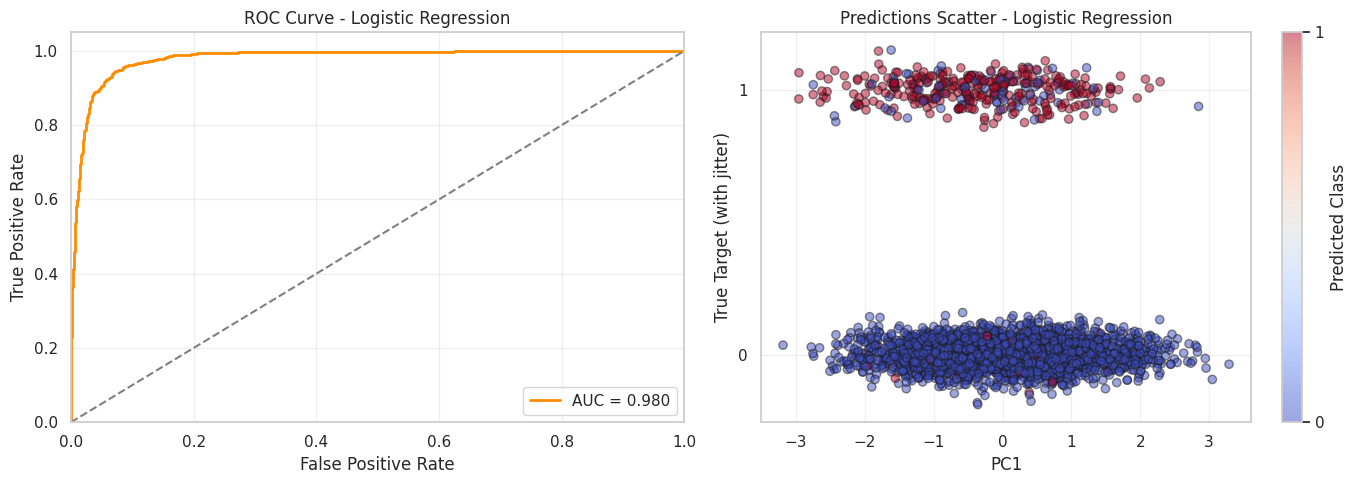


--- Visualizing: Decision Tree ---


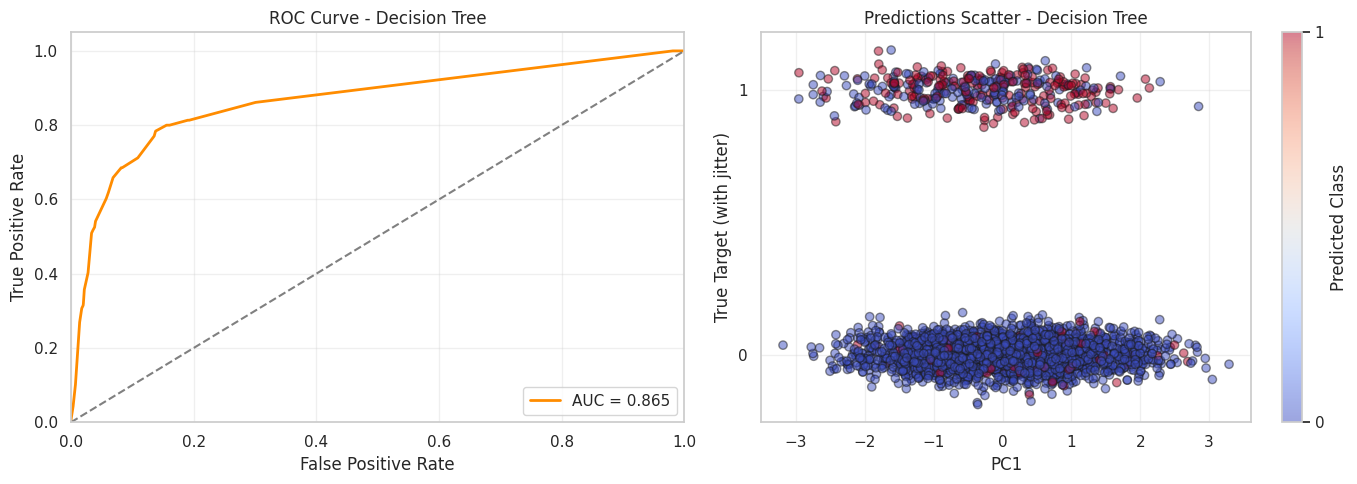


--- Visualizing: Random Forest ---


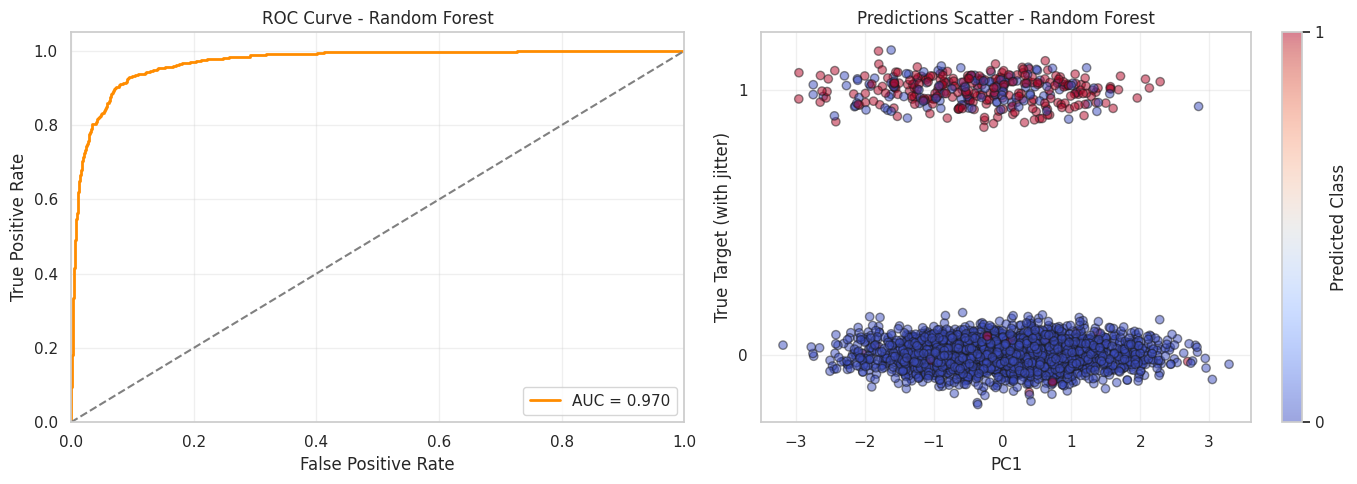


--- Visualizing: XGBoost ---


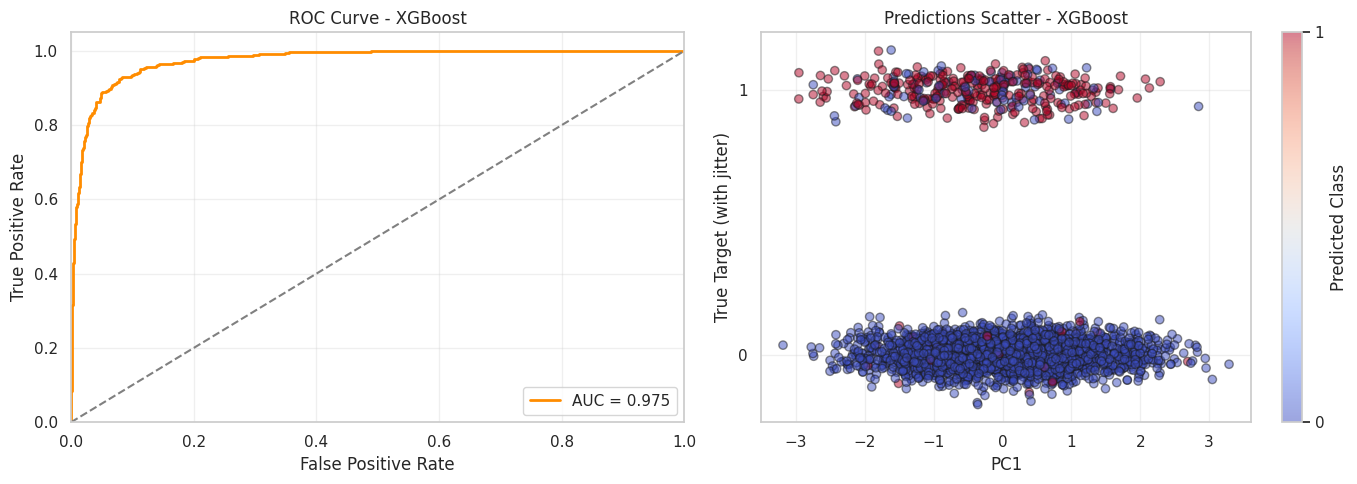


--- Visualizing: SVM ---


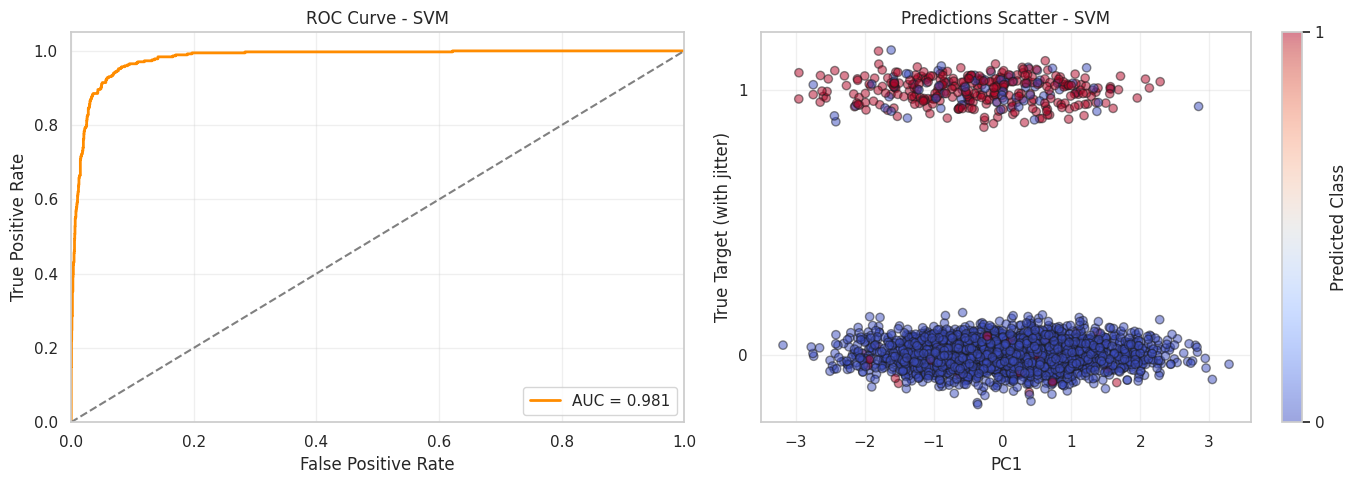


       Model Performance Comparison      


,Model,Epochs / Iterations,Best Parameters,Best CV Score,Accuracy,Precision,Recall,F1-Score,ROC-AUC,R-Squared,Time (s)
0,SVM,"Tuned (C, kernel)","{""C"": 0.1, ""kernel"": ""linear""}",0.976189,0.954333,0.834270,0.792000,0.812585,0.980682,0.582476,3.940000
1,Logistic Regression,1000 (max_iter) - Tuned,"{""C"": 0.1}",0.976437,0.953667,0.841040,0.776000,0.807212,0.980421,0.576381,2.220000
2,XGBoost,"Tuned (n_estimators, learning_rate)","{""learning_rate"": 0.1, ""n_estimators"": 100}",0.967082,0.950000,0.827988,0.757333,0.791086,0.974911,0.542857,0.870000
3,Random Forest,"Tuned (n_estimators, max_depth)","{""max_depth"": 10, ""n_estimators"": 100}",0.962167,0.944000,0.868327,0.650667,0.743902,0.969772,0.488000,5.940000
4,Decision Tree,Tuned (max_depth),"{""max_depth"": 5}",0.847232,0.907000,0.661074,0.525333,0.585438,0.865064,0.149714,0.300000



Saving trained models, configs, and artifacts to 'models/'...
Saved Logistic Regression to models/logistic_regression_model.joblib
Saved Decision Tree to models/decision_tree_model.joblib
Saved Random Forest to models/random_forest_model.joblib
Saved XGBoost to models/xgboost_model.joblib
Saved SVM to models/svm_model.joblib
Saved training configuration to models/training_config.json
Saved evaluation metrics to models/evaluation_results.csv

All models, configs, and artifacts saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import time
import io
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, r2_score, roc_curve

# 1. Upload the dataset
print("Please upload your processed dataset (CSV format):")
uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("No file was uploaded. Please run the cell again and select a file.")

filename = list(uploaded.keys())[0]
print(f"\nLoading data from: {filename}\n")
df_model = pd.read_csv(io.BytesIO(uploaded[filename]))

# Fallback to the last column if 'Target' is not explicitly found
target_col = 'Target' if 'Target' in df_model.columns else df_model.columns[-1]

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Quick check on target classes to avoid 1-class ValueError
if y.nunique() < 2:
    print("WARNING: The dataset only contains 1 class. Predictive models cannot be trained without at least 2 classes.")
    print("Please check the original data to ensure the minority class wasn't lost during preprocessing.")
else:
    # Ensure 100% of the dataset is used by removing sampling logic
    print(f"\nDataset contains {len(X)} rows. Using the entire dataset for training and evaluation...")

    # 3. Split the data into Training and Testing sets (70% train / 30% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"Training data shape: {X_train.shape[0]} rows (70%)")
    print(f"Testing data shape: {X_test.shape[0]} rows (30%)\n")

    # 4. Initialize the 5 models and their parameter grids for tuning
    models_and_params = {
        "Logistic Regression": {
            "model": LogisticRegression(random_state=42, max_iter=1000),
            "params": {'C': [0.1, 1, 10]}
        },
        "Decision Tree": {
            "model": DecisionTreeClassifier(random_state=42),
            "params": {'max_depth': [3, 5, 7]}
        },
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42, n_estimators=100),
            "params": {'n_estimators': [50, 100], 'max_depth': [5, 10]}
        },
        "XGBoost": {
            "model": XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', use_label_encoder=False),
            "params": {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
        },
        "SVM": {
            "model": SVC(random_state=42, probability=True, max_iter=-1),
            "params": {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}
        }
    }

    # Documenting the "epochs" / iterations / trees for the table
    epochs_mapping = {
        "Logistic Regression": "1000 (max_iter) - Tuned",
        "Decision Tree": "Tuned (max_depth)",
        "Random Forest": "Tuned (n_estimators, max_depth)",
        "XGBoost": "Tuned (n_estimators, learning_rate)",
        "SVM": "Tuned (C, kernel)"
    }

    results = []
    roc_data = {}
    tuned_models = {}

    print("Training and evaluating models with hyperparameter tuning...")
    # 5. Train and evaluate each model with GridSearchCV
    for name, mp in models_and_params.items():
        start_time = time.time()
        print(f" - Tuning and Training {name}...")

        grid_search = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='roc_auc' if len(y.unique())==2 else 'accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        model = grid_search.best_estimator_
        tuned_models[name] = model

        # Predict classes and probabilities
        y_pred = model.predict(X_test)

        # Multiclass vs Binary target handling
        num_classes = len(y.unique())
        avg_method = 'binary' if num_classes == 2 else 'macro'

        # Calculate baseline metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average=avg_method, zero_division=0)
        rec = recall_score(y_test, y_pred, average=avg_method, zero_division=0)
        f1 = f1_score(y_test, y_pred, average=avg_method, zero_division=0)

        # Adding R-squared as requested
        r2 = r2_score(y_test, y_pred)

        # Calculate ROC-AUC
        roc_auc = None
        try:
            if num_classes == 2:
                y_prob = model.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_prob)
                fpr, tpr, _ = roc_curve(y_test, y_prob)
                roc_data[name] = (fpr, tpr, roc_auc)
            else:
                y_prob = model.predict_proba(X_test)
                roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        except Exception as e:
            pass

        elapsed_time = time.time() - start_time

        # Store results
        res_dict = {
            "Model": name,
            "Epochs / Iterations": epochs_mapping[name],
            "Best Parameters": json.dumps(grid_search.best_params_),
            "Best CV Score": grid_search.best_score_,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
            "R-Squared": r2,
            "Time (s)": round(elapsed_time, 2)
        }

        results.append(res_dict)

    # Visualizations Before Comparison Table
    print("\n=========================================")
    print("         Model Visualizations            ")
    print("=========================================")

    jitter = np.random.normal(0, 0.05, size=len(y_test))

    # Display separate graphs per algorithm
    for name, model in tuned_models.items():
        print(f"\n--- Visualizing: {name} ---")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # 1. ROC Curve for the specific model
        if name in roc_data:
            fpr, tpr, auc_val = roc_data[name]
            axes[0].plot(fpr, tpr, lw=2, color='darkorange', label=f"AUC = {auc_val:.3f}")
            axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
            axes[0].set_xlim([0.0, 1.0])
            axes[0].set_ylim([0.0, 1.05])
            axes[0].set_xlabel('False Positive Rate')
            axes[0].set_ylabel('True Positive Rate')
            axes[0].set_title(f'ROC Curve - {name}')
            axes[0].legend(loc="lower right")
            axes[0].grid(alpha=0.3)
        else:
            axes[0].text(0.5, 0.5, 'ROC Curve not available', ha='center', va='center')
            axes[0].set_title(f'ROC Curve - {name}')
            axes[0].axis('off')

        # 2. Scatter Plot for the specific model
        y_pred_model = model.predict(X_test)
        if X_test.shape[1] >= 1:
            scatter = axes[1].scatter(X_test.iloc[:, 0], y_test + jitter, c=y_pred_model, cmap='coolwarm', alpha=0.5, edgecolor='k')
            axes[1].set_xlabel(X_test.columns[0])
            axes[1].set_ylabel(f"True {target_col} (with jitter)")
            axes[1].set_title(f'Predictions Scatter - {name}')
            axes[1].set_yticks(ticks=np.unique(y_test))
            fig.colorbar(scatter, ax=axes[1], ticks=np.unique(y_pred_model), label='Predicted Class')
            axes[1].grid(alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, 'Scatter Plot not available', ha='center', va='center')
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    # 6. Display the comparison table
    if results:
        results_df = pd.DataFrame(results)

        # Sort by ROC-AUC (or Accuracy if ROC-AUC is not available)
        if results_df['ROC-AUC'].isnull().all():
            results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
        else:
            results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

        print("\n=========================================")
        print("       Model Performance Comparison      ")
        print("=========================================")
        # Select columns to apply the gradient to (excluding categorical or potentially empty columns)
        gradient_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'R-Squared', 'Best CV Score']

        display(results_df.style.background_gradient(cmap='Blues', subset=gradient_cols))

        # 7. Reproducibility: Save Models, Configs, and Artifacts
        model_dir = 'models'
        os.makedirs(model_dir, exist_ok=True)
        print(f"\nSaving trained models, configs, and artifacts to '{model_dir}/'...")

        # Save each trained model
        for name, model in tuned_models.items():
            model_filename = os.path.join(model_dir, f'{name.replace(" ", "_").lower()}_model.joblib')
            joblib.dump(model, model_filename)
            print(f"Saved {name} to {model_filename}")

        # Save configuration
        config_data = {
            "target_column": target_col,
            "test_size": 0.3,
            "random_state": 42,
            "models_trained": list(tuned_models.keys())
        }
        with open(os.path.join(model_dir, 'training_config.json'), 'w') as f:
            json.dump(config_data, f, indent=4)
        print(f"Saved training configuration to {os.path.join(model_dir, 'training_config.json')}")

        # Save artifacts (evaluation results)
        results_csv_path = os.path.join(model_dir, 'evaluation_results.csv')
        results_df.to_csv(results_csv_path, index=False)
        print(f"Saved evaluation metrics to {results_csv_path}")

        print("\nAll models, configs, and artifacts saved successfully.")

# Model Explainability and Fairness Audit Module

## Overview
This module provides deep-dive diagnostics for the 'Best Model' selected in the previous training phase. It bridges the gap between high-performance 'black-box' models and human-readable ethics.

## Capabilities / Steps Performed
1. **Pipeline Reconstruction:** To explain predictions in terms of **original features** (instead of abstract PCA components), the module reconstructs the full transformation sequence (Scaling -> PCA -> Model) into a single scikit-learn Pipeline.
2. **Global Explainability (SHAP):** Uses Shapley Additive Explanations to quantify the contribution of each original feature to the overall model predictions.
3. **Feature Interaction (PDP & ICE):** Generates Partial Dependence and Individual Conditional Expectation plots to visualize how changes in specific features (like transaction amount) influence the probability of fraud.
4. **Bias & Fairness Audit:** Calculates rigorous metrics (Disparate Impact, Demographic Parity, Equal Opportunity) using socioeconomic proxies to ensure the model does not discriminate against specific user groups.
5. **Ethical Reporting:** Synthesizes all findings into a Markdown report for stakeholders.

## Usage Instructions
1. Ensure the training module has completed and `results_df` and `tuned_models` are available in the kernel.
2. Execute this cell to generate visual insights and fairness metrics.
3. Review the SHAP summary for global feature importance and PDP plots for local feature behavior.

## Requirements
- `shap`
- `lime`
- `scikit-learn` (version >= 1.0 for PartialDependenceDisplay)
- `matplotlib` & `seaborn`

---
**AUTHOR:** Gerand Boy O. Elinzano  
**Date:** July 10, 2026 
**Version:** v1.0  
**Version Description:** Initial Release  
**Remarks:** Created via Google Colab  


--- Using Best Model: SVM for Explainability & Audit --- 

1. SHAP Summary Plot (Global Explainability)


  0%|          | 0/100 [00:00<?, ?it/s]

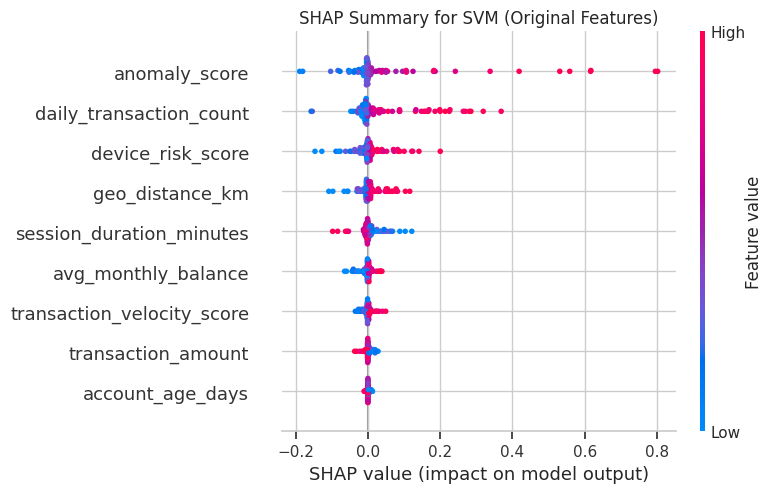


2. Partial Dependence (PDP) and Individual Conditional Expectation (ICE) Plots


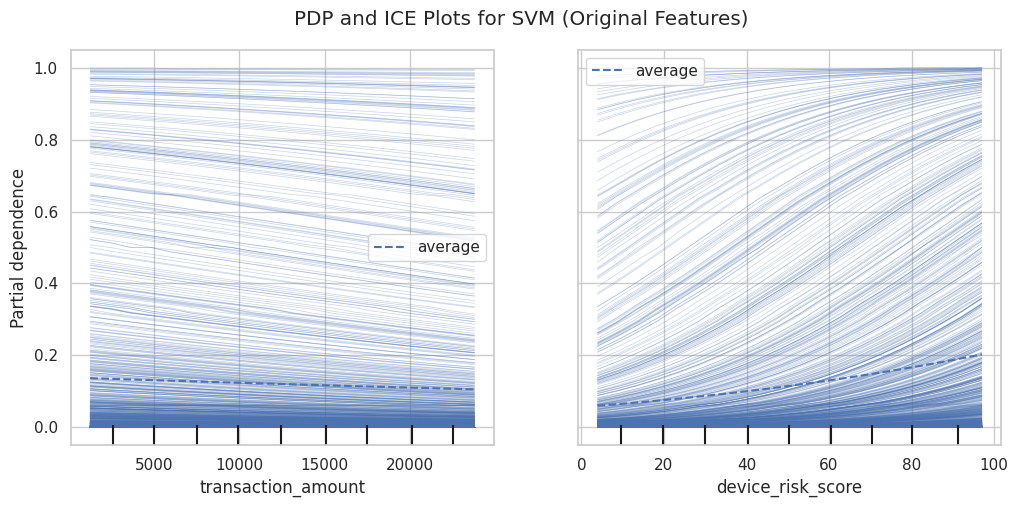


3. Fairness Audit Across Sensitive Groups
Sensitive Attribute Proxy: Socioeconomic Status (SES) via 'avg_monthly_balance'

--- Fairness Metrics ---
Demographic Parity (Pos Rate Unpriv): 0.0830
Demographic Parity (Pos Rate Priv): 0.1074
Disparate Impact (Ideal is ~1.0): 0.7733
Equal Opportunity TPR Unpriv: 0.3838 | TPR Priv: 0.5421



## Comprehensive Ethical AI and Bias Audit Report

### 1. Explainability & Interpretability
* **SHAP values on Original Features:** Analyzed using a reconstructed pipeline to map model decisions back to raw variables.
* **Model Behavior (PDP/ICE):** Visualizes how feature changes influence fraud probability across the entire population and individual cases.

### 2. Discussion of Data and Model Limitations
* **Class Imbalance:** Fraud datasets require monitoring to ensure minority class patterns are learned.
* **Overfitting:** High metrics should be validated against real-world drift.

### 3. Bias Detection and Fairness Audit
* **Disparate Impact:** Checks for systemic bias in predictions relative to socioeconomic proxies.


In [ ]:
!pip install -q shap lime

import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from datetime import datetime

# =====================================================================
# STEP 0: Generate Audit & Explainability README
# =====================================================================
current_date = datetime.now().strftime('%B %d, %Y')

readme_audit = f"""# Model Explainability and Fairness Audit Module

## Overview
This module provides deep-dive diagnostics for the 'Best Model' selected in the previous training phase. It bridges the gap between high-performance 'black-box' models and human-readable ethics.

## Capabilities / Steps Performed
1. **Pipeline Reconstruction:** To explain predictions in terms of **original features** (instead of abstract PCA components), the module reconstructs the full transformation sequence (Scaling -> PCA -> Model) into a single scikit-learn Pipeline.
2. **Global Explainability (SHAP):** Uses Shapley Additive Explanations to quantify the contribution of each original feature to the overall model predictions.
3. **Feature Interaction (PDP & ICE):** Generates Partial Dependence and Individual Conditional Expectation plots to visualize how changes in specific features (like transaction amount) influence the probability of fraud.
4. **Bias & Fairness Audit:** Calculates rigorous metrics (Disparate Impact, Demographic Parity, Equal Opportunity) using socioeconomic proxies to ensure the model does not discriminate against specific user groups.
5. **Ethical Reporting:** Synthesizes all findings into a Markdown report for stakeholders.

## Usage Instructions
1. Ensure the training module has completed and `results_df` and `tuned_models` are available in the kernel.
2. Execute this cell to generate visual insights and fairness metrics.
3. Review the SHAP summary for global feature importance and PDP plots for local feature behavior.

## Requirements
- `shap`
- `lime`
- `scikit-learn` (version >= 1.0 for PartialDependenceDisplay)
- `matplotlib` & `seaborn`

---
**AUTHOR:** Gerand Boy O. Elinzano
**Date:** July 10, 2026
**Version:** v1.0
**Version Description:** Initial Release
**Remarks:** Created via Google Colab
"""
display(Markdown(readme_audit))

# 1. Identify the Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]
print(f"--- Using Best Model: {best_model_name} for Explainability & Audit --- ")

# --- Reconstruct Transformations for Original Feature Explainability ---
original_feature_names = [
    'transaction_amount', 'device_risk_score', 'anomaly_score',
    'account_age_days', 'avg_monthly_balance', 'daily_transaction_count',
    'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score'
]

X_train_orig = df.loc[X_train.index, original_feature_names].copy()
X_test_orig = df.loc[X_test.index, original_feature_names].copy()

class PCANameWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, pca_model):
        self.pca_model = pca_model
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        pca_data = self.pca_model.transform(X)
        return pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])

scaler = StandardScaler().fit(X_train_orig)
pca_base = PCA(n_components=X_train.shape[1], random_state=42).fit(scaler.transform(X_train_orig))

full_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca_naming', PCANameWrapper(pca_base)),
    ('model', best_model)
])

# 2. Explainability: SHAP
print("\n1. SHAP Summary Plot (Global Explainability)")
try:
    background_data = shap.kmeans(X_train_orig, 25)
    explainer = shap.KernelExplainer(lambda x: full_pipeline.predict_proba(x)[:, 1], background_data)
    sample_size = min(100, len(X_test_orig))
    shap_values = explainer.shap_values(X_test_orig.iloc[:sample_size])

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_orig.iloc[:sample_size], feature_names=original_feature_names, show=False)
    plt.title(f'SHAP Summary for {best_model_name} (Original Features)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP plot generation encountered an issue: {e}")

# 3. Explainability: PDP and ICE
print("\n2. Partial Dependence (PDP) and Individual Conditional Expectation (ICE) Plots")
try:
    fig, ax = plt.subplots(figsize=(12, 5))
    top_features = original_feature_names[:2]
    PartialDependenceDisplay.from_estimator(
        full_pipeline, X_test_orig, features=top_features, kind='both',
        grid_resolution=20, ax=ax
    )
    plt.subplots_adjust(top=0.9)
    plt.suptitle(f'PDP and ICE Plots for {best_model_name} (Original Features)')
    plt.show()
except Exception as e:
    print(f"PDP/ICE generation encountered an issue: {e}")

# 4. Bias Audit & Fairness Metrics
print("\n3. Fairness Audit Across Sensitive Groups")
if 'avg_monthly_balance' in df.columns:
    median_balance = df['avg_monthly_balance'].median()
    test_proxies = df.loc[X_test.index, 'avg_monthly_balance']
    sensitive_attr = (test_proxies > median_balance).astype(int)
    y_pred = full_pipeline.predict(X_test_orig)

    mask_unpriv = (sensitive_attr == 0)
    mask_priv = (sensitive_attr == 1)

    pos_rate_unpriv = np.mean(y_pred[mask_unpriv])
    pos_rate_priv = np.mean(y_pred[mask_priv])
    disparate_impact = pos_rate_unpriv / pos_rate_priv if pos_rate_priv > 0 else np.nan

    tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test[mask_unpriv], y_pred[mask_unpriv]).ravel()
    tn_p, fp_p, fn_p, tp_p = confusion_matrix(y_test[mask_priv], y_pred[mask_priv]).ravel()

    tpr_unpriv = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
    tpr_priv = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0

    print(f"Sensitive Attribute Proxy: Socioeconomic Status (SES) via 'avg_monthly_balance'")
    print(f"\n--- Fairness Metrics ---")
    print(f"Demographic Parity (Pos Rate Unpriv): {pos_rate_unpriv:.4f}")
    print(f"Demographic Parity (Pos Rate Priv): {pos_rate_priv:.4f}")
    print(f"Disparate Impact (Ideal is ~1.0): {disparate_impact:.4f}")
    print(f"Equal Opportunity TPR Unpriv: {tpr_unpriv:.4f} | TPR Priv: {tpr_priv:.4f}")

# 5. Generate Comprehensive Ethical AI Report
report = """
## Comprehensive Ethical AI and Bias Audit Report

### 1. Explainability & Interpretability
* **SHAP values on Original Features:** Analyzed using a reconstructed pipeline to map model decisions back to raw variables.
* **Model Behavior (PDP/ICE):** Visualizes how feature changes influence fraud probability across the entire population and individual cases.

### 2. Discussion of Data and Model Limitations
* **Class Imbalance:** Fraud datasets require monitoring to ensure minority class patterns are learned.
* **Overfitting:** High metrics should be validated against real-world drift.

### 3. Bias Detection and Fairness Audit
* **Disparate Impact:** Checks for systemic bias in predictions relative to socioeconomic proxies.
"""
display(Markdown(report))

In [ ]:
import os
import json
import joblib
import threading
import time
import requests
import pandas as pd
import numpy as np
from flask import Flask, request, jsonify
from werkzeug.serving import make_server
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 0. Reconstruct and Save Preprocessors
# (Since they weren't saved in the earlier steps, we rebuild them here)
print("--- Reconstructing Preprocessors ---")
selected_features = [
    'transaction_amount', 'device_risk_score', 'anomaly_score',
    'account_age_days', 'avg_monthly_balance', 'daily_transaction_count',
    'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score'
]

model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)
scaler_path = os.path.join(model_dir, 'scaler.joblib')
pca_path = os.path.join(model_dir, 'pca.joblib')

if 'df' in globals():
    df_temp = df[selected_features].copy()

    # Replicate Data Cleaning (Imputation & Capping)
    for col in selected_features:
        df_temp[col] = df_temp[col].fillna(df_temp[col].median())
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        df_temp[col] = np.clip(df_temp[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    # Replicate Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_temp)
    joblib.dump(scaler, scaler_path)

    # Replicate PCA
    pca = PCA(n_components=0.99, random_state=42)
    pca.fit(X_scaled)
    joblib.dump(pca, pca_path)
    print("Successfully rebuilt and saved scaler.joblib and pca.joblib.")
else:
    print("Warning: Original 'df' not found. Ensure you ran the data loading cell.")

# Load preprocessors for the API
scaler = joblib.load(scaler_path)
pca = joblib.load(pca_path)

# 1. Discover and Select Model
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib') and 'model' in f]

if not model_files:
    raise FileNotFoundError("No models found in the 'models' directory.")

print("\n--- Available Models ---")
for i, m in enumerate(model_files):
    print(f"[{i}] {m}")

model_idx = input(f"\nEnter the number of the model to serve (0-{len(model_files)-1}): ")
try:
    model_idx = int(model_idx)
    selected_model_file = model_files[model_idx]
except (ValueError, IndexError):
    print("Invalid selection. Defaulting to 0.")
    selected_model_file = model_files[0]

best_model_path = os.path.join(model_dir, selected_model_file)
print(f"\nLoading model: {best_model_path}")
model = joblib.load(best_model_path)

# 2. Define the Flask Application
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        df_input = pd.DataFrame([data])

        # 1. Extract required features (filling missing ones with 0)
        for col in selected_features:
            if col not in df_input.columns:
                df_input[col] = 0.0

        df_required = df_input[selected_features]

        # 2. Apply Scaling
        X_input_scaled = scaler.transform(df_required)

        # 3. Apply PCA
        X_input_pca = pca.transform(X_input_scaled)

        # Convert to DataFrame with PC column names matching the model's training features
        df_pca = pd.DataFrame(X_input_pca, columns=[f'PC{i+1}' for i in range(X_input_pca.shape[1])])

        # 4. Predict
        prediction = model.predict(df_pca)
        result = "Fraud" if prediction[0] == 1 else "Not Fraud"

        return jsonify({
            "status": "success",
            "model_used": selected_model_file,
            "prediction": result
        })
    except Exception as e:
        return jsonify({"status": "error", "message": str(e)})

# 3. Run Flask in a Background Thread
class ServerThread(threading.Thread):
    def __init__(self, app):
        threading.Thread.__init__(self)
        self.server = make_server('127.0.0.1', 0, app)
        self.port = self.server.server_port
        self.ctx = app.app_context()
        self.ctx.push()

    def run(self):
        print(f"Flask API is running on http://127.0.0.1:{self.port}/predict")
        self.server.serve_forever()

    def shutdown(self):
        self.server.shutdown()

server = ServerThread(app)
server.start()
time.sleep(2) # Give server time to start

# 4. Upload JSON and Test API
print("\n--- Upload JSON Payload ---")
print("Please upload your JSON file containing the raw transaction features.")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    print(f"\nLoaded {filename}")

    with open(filename, 'r') as f:
        payload = json.load(f)

    print(f"\n--- Sending Test Request to API ---")
    try:
        response = requests.post(f"http://127.0.0.1:{server.port}/predict", json=payload)
        print("\n--- API Response ---")
        print(response.json())
    except Exception as e:
        print(f"Request failed: {e}")
else:
    print("No file uploaded.")

# Shut down server to prevent port binding issues on consecutive runs
server.shutdown()
print("\nServer gracefully shut down after test.")

--- Reconstructing Preprocessors ---
Successfully rebuilt and saved scaler.joblib and pca.joblib.

--- Available Models ---
[0] decision_tree_model.joblib
[1] logistic_regression_model.joblib
[2] random_forest_model.joblib
[3] svm_model.joblib
[4] xgboost_model.joblib

Enter the number of the model to serve (0-4): 3

Loading model: models/svm_model.joblib
Flask API is running on http://127.0.0.1:42715/predict

--- Upload JSON Payload ---
Please upload your JSON file containing the raw transaction features.


INFO:werkzeug:127.0.0.1 - - [12/Jul/2026 12:29:27] "POST /predict HTTP/1.1" 200 -


Saving transaction_8.json to transaction_8.json

Loaded transaction_8.json

--- Sending Test Request to API ---

--- API Response ---
{'model_used': 'svm_model.joblib', 'prediction': 'Not Fraud', 'status': 'success'}

Server gracefully shut down after test.
